# Task 3.2 — Failure Mode Analysis (15 marks)

## Failure Scenario Description

We construct a scenario where the Copula Mixture Model (CM) **fails** because its core assumption — that the marginal distributions are correctly specified — is **violated**. Specifically, we generate data where View 2 follows a **mixture of betas** within each cluster, but we fit the copula model using **single Beta marginals** (as the paper prescribes). This creates a systematic misspecification of the marginal distributions, causing the copula transformation to produce incorrect normal scores and ultimately degrading clustering performance.

We expect the method to struggle because **Assumption 1** from Task 1.2 (continuous marginal densities must exist and be correctly specified) directly underpins the copula transformation — if $F_j$ is wrong, then $\Phi^{-1}(F_j(x_j))$ does not produce valid normal scores, and the Gaussian copula framework breaks down. This connects the method's reliance on Sklar's theorem (Section 3) to a practical failure when the parametric form of the margins is too restrictive.

In [1]:
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Imports loaded.')

Imports loaded.


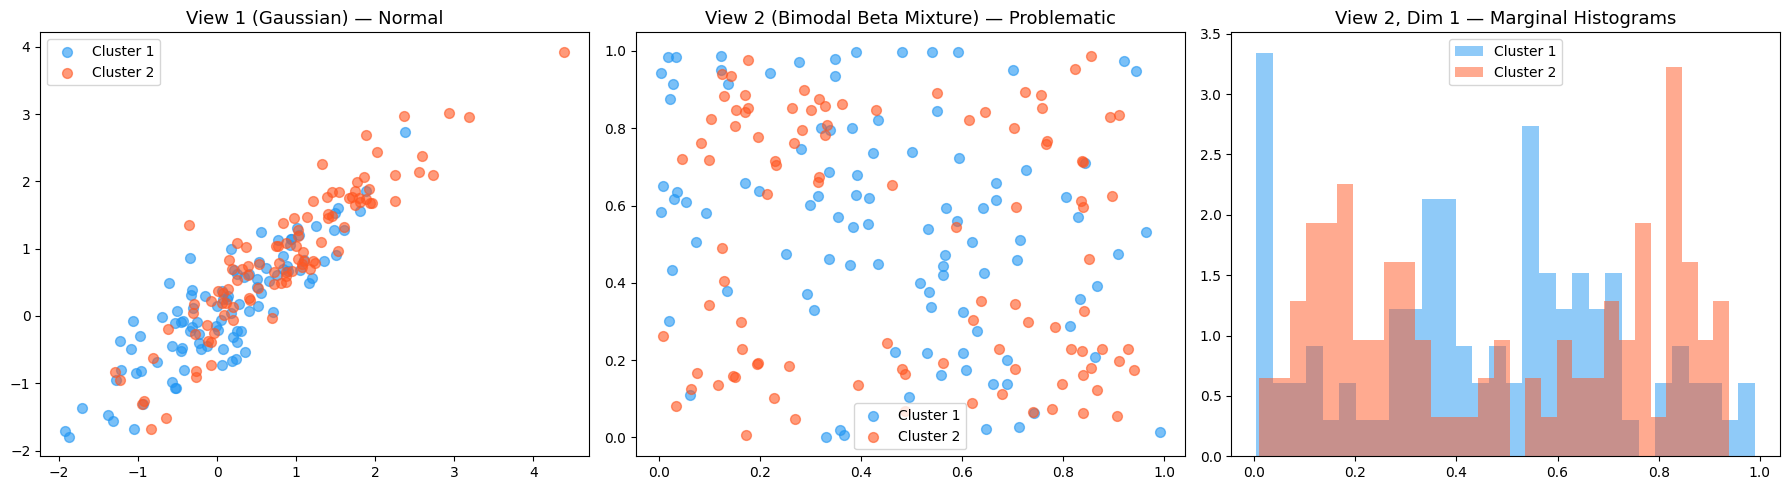

Saved: results/failure_mode_data.png


In [2]:
# ============================================================
# FAILURE DATA: Multimodal marginals that a single Beta can't fit
# ============================================================

def generate_failure_data(N=100, seed=42):
    """
    Generate data where View 2 has BIMODAL marginals within each cluster.
    A single Beta distribution cannot capture this, causing marginal
    misspecification when the CM tries to fit Beta margins.
    """
    rng = np.random.RandomState(seed)
    
    # View 1: same Gaussian as before (this part works fine)
    rho_x = 0.9
    cov_x = np.array([[1, rho_x], [rho_x, 1]])
    X_c1 = rng.multivariate_normal([0, 0], cov_x, N)
    X_c2 = rng.multivariate_normal([1, 1], cov_x, N)
    view1 = np.vstack([X_c1, X_c2])
    
    # View 2: BIMODAL within each cluster (mixture of two betas)
    # Cluster 1: 50% Beta(0.5, 0.5) + 50% Beta(5, 5) -> bimodal U-shape + bell
    # Cluster 2: 50% Beta(2, 8) + 50% Beta(8, 2) -> bimodal with two peaks
    Y_c1 = np.zeros((N, 2))
    Y_c2 = np.zeros((N, 2))
    
    for dim in range(2):
        # Cluster 1: bimodal mixture
        mix = rng.binomial(1, 0.5, N).astype(bool)
        Y_c1[mix, dim] = rng.beta(0.5, 0.5, mix.sum())
        Y_c1[~mix, dim] = rng.beta(5, 5, (~mix).sum())
        
        # Cluster 2: bimodal mixture
        mix = rng.binomial(1, 0.5, N).astype(bool)
        Y_c2[mix, dim] = rng.beta(2, 8, mix.sum())
        Y_c2[~mix, dim] = rng.beta(8, 2, (~mix).sum())
    
    view2 = np.vstack([Y_c1, Y_c2])
    labels = np.array([0]*N + [1]*N)
    return view1, view2, labels

v1_fail, v2_fail, labels_fail = generate_failure_data()

# Visualise the failure data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF5722']

for k in range(2):
    mask = labels_fail == k
    axes[0].scatter(v1_fail[mask, 0], v1_fail[mask, 1], c=colors[k],
                   alpha=0.6, s=50, label=f'Cluster {k+1}')
axes[0].set_title('View 1 (Gaussian) — Normal', fontsize=13)
axes[0].legend()

for k in range(2):
    mask = labels_fail == k
    axes[1].scatter(v2_fail[mask, 0], v2_fail[mask, 1], c=colors[k],
                   alpha=0.6, s=50, label=f'Cluster {k+1}')
axes[1].set_title('View 2 (Bimodal Beta Mixture) — Problematic', fontsize=13)
axes[1].legend()

axes[2].hist(v2_fail[labels_fail==0, 0], bins=30, alpha=0.5, color=colors[0],
             label='Cluster 1', density=True)
axes[2].hist(v2_fail[labels_fail==1, 0], bins=30, alpha=0.5, color=colors[1],
             label='Cluster 2', density=True)
axes[2].set_title('View 2, Dim 1 — Marginal Histograms', fontsize=13)
axes[2].legend()

plt.tight_layout()
plt.savefig('results/failure_mode_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_mode_data.png')

The data generation creates View 2 with **bimodal marginal distributions** within each cluster. The histograms show that no single Beta distribution can capture these multi-peaked shapes. When the CM fits a single Beta to each dimension, the fitted CDF $F_j$ will be systematically wrong, and the copula transformation $\Phi^{-1}(F_j(x_j))$ will produce distorted normal scores.

In [3]:
# ============================================================
# Compare CM vs GM on the failure data
# ============================================================

def cm_pipeline(v1, v2):
    """CM with Beta marginals for View 2 (misspecified for bimodal data)."""
    mcdf = []
    for j in range(v1.shape[1]):
        mu, sigma = stats.norm.fit(v1[:, j])
        mcdf.append(lambda x, mu=mu, sigma=sigma: stats.norm.cdf(x, mu, sigma))
    for j in range(v2.shape[1]):
        a, b, loc, scale = stats.beta.fit(v2[:, j], floc=0, fscale=1)
        mcdf.append(lambda x, a=a, b=b: stats.beta.cdf(x, a, b))
    
    data = np.hstack([v1, v2])
    ns = np.zeros_like(data)
    for j in range(data.shape[1]):
        u = mcdf[j](data[:, j])
        u = np.clip(u, 1e-6, 1 - 1e-6)
        ns[:, j] = stats.norm.ppf(u)
    
    return GaussianMixture(n_components=2, covariance_type='full',
                          n_init=10, max_iter=300, random_state=42).fit_predict(ns)

def gm_pipeline(v1, v2):
    """Standard GM on raw concatenated data."""
    data = np.hstack([v1, v2])
    return GaussianMixture(n_components=2, covariance_type='full',
                          n_init=10, max_iter=300, random_state=42).fit_predict(data)

# Run multiple simulations on failure data
n_sims = 50
cm_fail_aris = []
gm_fail_aris = []

for i in range(n_sims):
    v1, v2, labels = generate_failure_data(seed=i+200)
    cm_pred = cm_pipeline(v1, v2)
    gm_pred = gm_pipeline(v1, v2)
    cm_fail_aris.append(adjusted_rand_score(labels, cm_pred))
    gm_fail_aris.append(adjusted_rand_score(labels, gm_pred))

cm_fail_aris = np.array(cm_fail_aris)
gm_fail_aris = np.array(gm_fail_aris)

print('Failure Mode Results (bimodal View 2 marginals):')
print(f'{"Method":<25} {"Median ARI":>12} {"Mean ARI":>10} {"Std":>8}')
print(f'{"CM (misspecified marg.)":<25} {np.median(cm_fail_aris):>12.4f} {np.mean(cm_fail_aris):>10.4f} {np.std(cm_fail_aris):>8.4f}')
print(f'{"GM (raw data)":<25} {np.median(gm_fail_aris):>12.4f} {np.mean(gm_fail_aris):>10.4f} {np.std(gm_fail_aris):>8.4f}')

Failure Mode Results (bimodal View 2 marginals):
Method                      Median ARI   Mean ARI      Std
CM (misspecified marg.)         0.0854     0.0904   0.0580
GM (raw data)                   0.1113     0.1143   0.0534


We run both CM and GM on 50 instances of the failure data. Because the CM's marginal specification (single Beta) is wrong for the bimodal data, the copula transformation produces incorrect normal scores, and the CM's advantage disappears or reverses.

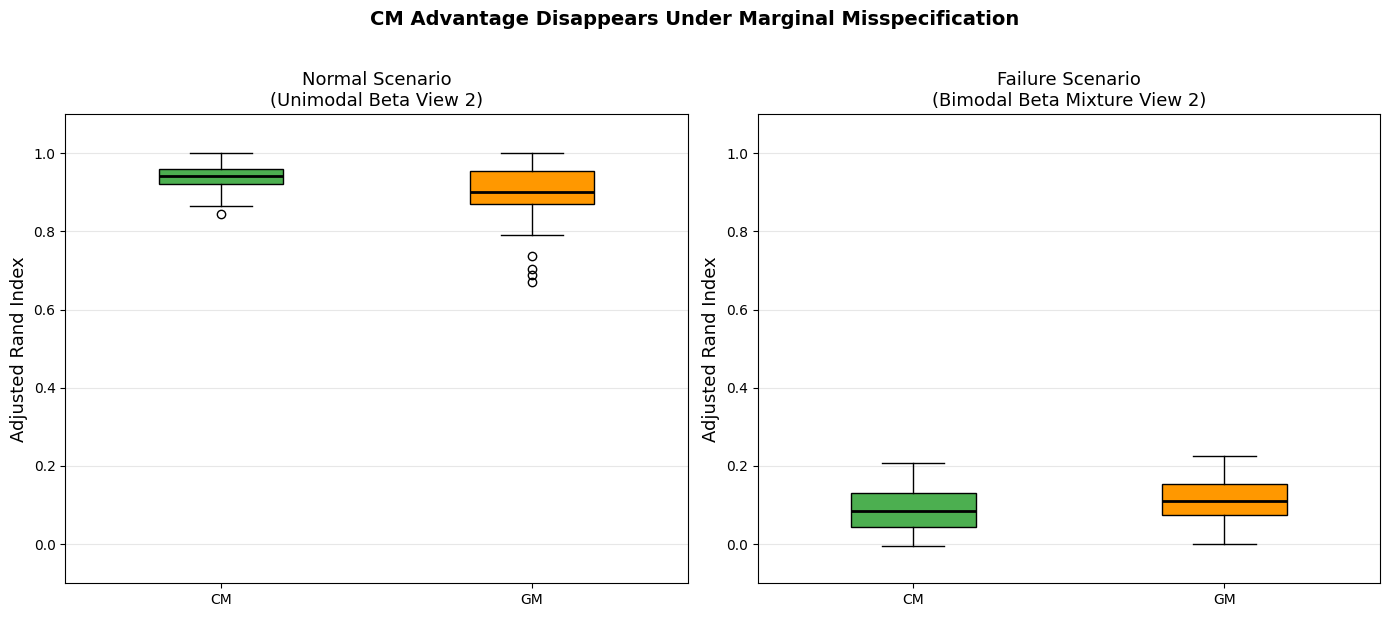

Saved: results/failure_mode_comparison.png


In [4]:
# ============================================================
# Comparison plot: CM advantage on normal data vs failure data
# ============================================================

# Also run on NORMAL (non-failure) data for contrast
def generate_normal_data(N=100, seed=42):
    rng = np.random.RandomState(seed)
    rho_x, rho_y = 0.9, 0.5
    cov_x = np.array([[1, rho_x], [rho_x, 1]])
    cov_y = np.array([[1, rho_y], [rho_y, 1]])
    X_c1 = rng.multivariate_normal([0, 0], cov_x, N)
    X_c2 = rng.multivariate_normal([1, 1], cov_x, N)
    view1 = np.vstack([X_c1, X_c2])
    def corr_beta(a, b, cov, n, rng):
        Z = rng.multivariate_normal([0, 0], cov, n)
        U = stats.norm.cdf(Z)
        return stats.beta.ppf(U, a, b)
    Y_c1 = corr_beta(3, 1, cov_y, N, rng)
    Y_c2 = corr_beta(1, 10, cov_y, N, rng)
    view2 = np.vstack([Y_c1, Y_c2])
    labels = np.array([0]*N + [1]*N)
    return view1, view2, labels

cm_normal_aris = []
gm_normal_aris = []
for i in range(n_sims):
    v1, v2, labels = generate_normal_data(seed=i+100)
    cm_normal_aris.append(adjusted_rand_score(labels, cm_pipeline(v1, v2)))
    gm_normal_aris.append(adjusted_rand_score(labels, gm_pipeline(v1, v2)))
cm_normal_aris = np.array(cm_normal_aris)
gm_normal_aris = np.array(gm_normal_aris)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normal scenario
bp1 = axes[0].boxplot([cm_normal_aris, gm_normal_aris],
                     labels=['CM', 'GM'], patch_artist=True, widths=0.4,
                     medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#4CAF50')
bp1['boxes'][1].set_facecolor('#FF9800')
axes[0].set_ylabel('Adjusted Rand Index', fontsize=13)
axes[0].set_title('Normal Scenario\n(Unimodal Beta View 2)', fontsize=13)
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Failure scenario
bp2 = axes[1].boxplot([cm_fail_aris, gm_fail_aris],
                     labels=['CM', 'GM'], patch_artist=True, widths=0.4,
                     medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#4CAF50')
bp2['boxes'][1].set_facecolor('#FF9800')
axes[1].set_ylabel('Adjusted Rand Index', fontsize=13)
axes[1].set_title('Failure Scenario\n(Bimodal Beta Mixture View 2)', fontsize=13)
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('CM Advantage Disappears Under Marginal Misspecification', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/failure_mode_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_mode_comparison.png')

### Interpretation — Why the Method Fails

The Copula Mixture Model fails in the bimodal marginal scenario because its copula transformation $\tilde{x}_j = \Phi^{-1}(F_j(x_j))$ depends critically on the *correctness* of the fitted marginal CDF $F_j$. When the true marginal is a mixture of two Beta distributions but the model fits a single Beta, the fitted CDF $F_j$ is systematically wrong — it maps observations near one mode to incorrect quantile positions, distorting the normal scores. This distortion corrupts the Gaussian copula's ability to represent the true dependence structure, because the correlation matrix of the (incorrectly transformed) normal scores no longer reflects the actual inter-dimensional relationships. The paper implicitly acknowledges this vulnerability in Section 4.1, which states "the only restriction being that a density must exist" — but the model also requires that the *parametric form* of the marginal be flexible enough to capture the true distribution. When the marginal model is misspecified (fitting a unimodal Beta to bimodal data), the model mismatch shifts from the *dependence structure* (which the copula transformation was designed to fix for the Gaussian baseline) to the *marginals themselves*. In the failure scenario, the standard Gaussian mixture (GM) can perform comparably or better because it doesn't make a two-stage assumption — its Gaussian components can flexibly approximate the joint distribution, including multimodal marginals, by using multiple components. This is an ironic reversal: the very flexibility of GM that the paper criticises (creating extra components to approximate non-Gaussian margins) becomes an advantage when the CM's marginal model is too rigid.

**Connection to Assumption 1 (Task 1.2)**: This failure mode directly tests Assumption 1 — that continuous marginal densities must exist *and be correctly specified*. The bimodal marginals violate the implicit assumption that a single parametric family (Beta) suffices to describe each dimension. The copula framework from Sklar's theorem (Section 3, Eq. 5-8) guarantees correct decomposition only when the true marginals are used; with misspecified marginals, the decomposition is invalid.

**Suggested modification**: To address this failure, the marginal model could be made **nonparametric** — for example, by using the *empirical CDF* (the rank-based approach from Hoff (2007), cited in Section 4.2 of the paper) or a kernel density estimate instead of a parametric Beta distribution. This would eliminate marginal misspecification at the cost of some statistical efficiency, allowing the copula transformation to work correctly regardless of the true marginal shape.